# Animal Cancer Disease Prediction

## Problem statement

This notebook demonstrates a complete binary image-classification workflow for animal cell or tissue samples. It uses the same preprocessing and deterministic demo classifier as the Streamlit application.

> **Medical disclaimer:** This project is for educational purposes only and should not be used as a medical diagnosis tool.

## Dataset explanation

A real veterinary pathology dataset is not bundled because medical images require appropriate consent, licensing, expert labels, and careful privacy controls. Instead, this notebook creates a seeded synthetic dataset:

- **Non-cancerous demo patterns:** smoother, lower-contrast colour fields.
- **Cancerous demo patterns:** more irregular, high-contrast, saturated, and red-emphasized fields.

These patterns illustrate the pipeline and are not simulations of real disease.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

# Work both from this project directory and from the repository root.
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "src").is_dir():
    PROJECT_DIR = PROJECT_DIR / "Animal_Cancer_Disease_Prediction"
if not (PROJECT_DIR / "src").is_dir():
    raise RuntimeError("Run this notebook from the repository or project directory.")
sys.path.insert(0, str(PROJECT_DIR))

from src.model_utils import CLASS_LABELS, create_demo_model, predict_with_confidence
from src.preprocessing import normalize_pixels, resize_image

RANDOM_SEED = 1871
IMAGE_SIZE = (128, 128)
rng = np.random.default_rng(RANDOM_SEED)

## Generate synthetic demo images

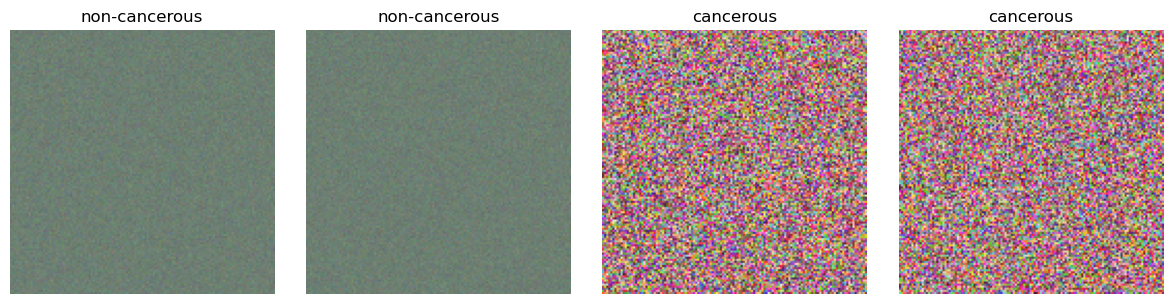

In [2]:
def make_synthetic_image(label, size=IMAGE_SIZE):
    """Create one reproducible pattern for pipeline demonstration."""
    width, height = size
    if label == 0:
        base = np.array([0.43, 0.50, 0.45], dtype=np.float32)
        array = rng.normal(base, 0.025, size=(height, width, 3))
    else:
        array = rng.uniform(0.08, 0.92, size=(height, width, 3))
        array[..., 0] = np.clip(array[..., 0] + 0.16, 0.0, 1.0)
    return Image.fromarray((np.clip(array, 0, 1) * 255).astype(np.uint8), mode="RGB")


images = []
true_labels = []
for class_index in range(2):
    for _ in range(60):
        images.append(make_synthetic_image(class_index))
        true_labels.append(class_index)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for axis, index in zip(axes, [0, 1, 60, 61]):
    axis.imshow(images[index])
    axis.set_title(CLASS_LABELS[true_labels[index]])
    axis.axis("off")
plt.tight_layout()

## Preprocessing

The reusable module performs four steps for application inputs: extension validation, safe decoding, RGB conversion, and EXIF correction. Images are then resized to 128 × 128 pixels and normalized from integer values in `[0, 255]` to `float32` values in `[0, 1]`.

In [3]:
processed_images = np.stack([
    normalize_pixels(resize_image(image, IMAGE_SIZE)) for image in images
])
y_true = np.asarray(true_labels)

print("Batch shape:", processed_images.shape)
print("Data type:", processed_images.dtype)
print("Pixel range:", processed_images.min(), "to", processed_images.max())

Batch shape: (120, 128, 128, 3)
Data type: float32
Pixel range: 0.078431375 to 1.0


## Demo classifier logic

The project deliberately uses a transparent deterministic classifier instead of claiming a trained medical model. It extracts contrast, edge density, saturation, and red excess. A fixed weighted sum plus a sigmoid produces a cancer-like pattern score. In a future research version, the class can be replaced by a validated CNN without changing the upload or preprocessing pipeline.

In [4]:
model = create_demo_model()
print("Demo model weights:", model.weights)

predictions = [predict_with_confidence(model, image) for image in processed_images]
y_pred = np.array([CLASS_LABELS.index(prediction.label) for prediction in predictions])
confidences = np.array([prediction.confidence for prediction in predictions])

Demo model weights: {'bias': -1.35, 'contrast': 3.0, 'edge_density': 2.4, 'saturation': 1.1, 'red_excess': 1.0}


## Evaluation metrics

Accuracy measures all correct predictions. Precision describes how often predicted cancerous patterns are labelled cancerous in the synthetic data. Recall measures how many synthetic cancerous patterns are found. F1-score balances precision and recall. The confusion matrix shows correct and incorrect counts by class.

Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1 Score: 1.000


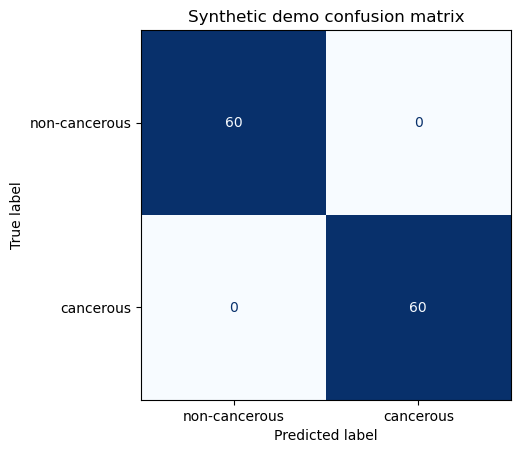

In [5]:
metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1_score": f1_score(y_true, y_pred, zero_division=0),
}
for name, value in metrics.items():
    print(f"{name.replace('_', ' ').title()}: {value:.3f}")

matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(matrix, display_labels=CLASS_LABELS)
display.plot(cmap="Blues", colorbar=False)
plt.title("Synthetic demo confusion matrix")
plt.show()

## Sample prediction

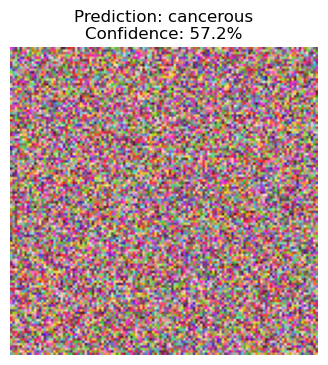

Prediction(label='cancerous', confidence=0.5715813940515168, cancer_probability=0.5715813940515168)

In [6]:
sample_index = 75
sample_prediction = predict_with_confidence(model, processed_images[sample_index])

plt.figure(figsize=(4, 4))
plt.imshow(images[sample_index])
plt.title(
    f"Prediction: {sample_prediction.label}\n"
    f"Confidence: {sample_prediction.confidence:.1%}"
)
plt.axis("off")
plt.show()
sample_prediction

## Conclusion and limitations

This notebook connects reproducible data generation, shared preprocessing, deterministic inference, standard classification metrics, visualization, and a sample prediction. The architecture is suitable for learning and software testing.

Its results are limited to intentionally separable synthetic patterns. They do not measure biological validity, generalization, fairness, or diagnostic safety. Real research would need ethically sourced and expert-labelled images, patient-level data splits, a trained model, external validation, calibration, bias assessment, and veterinary oversight.

**This project is for educational purposes only and should not be used as a medical diagnosis tool.**